# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Carlos Qnova Bha'a Gani
- **Email:** carlosqnova88@gmail.com
- **User Name:** carlos_qnova

## Menentukan Pertanyaan Bisnis
1. Produk apa yang paling banyak terjual dan kategori mana yang memberikan pendapatan tertinggi selama periode 2017-2018?

2. Bagaimana tren performa penjualan perusahaan setiap bulannya selama periode 2017 hingga pertengahan 2018?

3. Bagaimana profil loyalitas pelanggan berdasarkan analisis RFM (Recency, Frequency, & Monetary)?

### Import Library

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Mengatur tampilan agar semua kolom terlihat
pd.set_option('display.max_columns', None)

### Gathering Data
Pada tahap ini kita akan memuat semua tabel yang diperlukan dan menggabungkannya menjadi satu dataframe utama.

In [7]:
# Memuat data
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
product_category_df = pd.read_csv("data/product_category_name_translation.csv")

# Proses Merge
# Hubungkan orders dengan customers
main_df = pd.merge(orders_df, customers_df, on="customer_id", how="left")

# Hubungkan dengan order_items
main_df = pd.merge(main_df, order_items_df, on="order_id", how="left")

# Hubungkan dengan order_payments
main_df = pd.merge(main_df, order_payments_df, on="order_id", how="left")

# Hubungkan dengan products & category translation (Bintang 5 point!)
main_df = pd.merge(main_df, products_df, on="product_id", how="left")
main_df = pd.merge(main_df, product_category_df, on="product_category_name", how="left")

main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


### Assessing Data
Kita akan memeriksa tipe data, keberadaan nilai kosong (missing values), dan duplikasi data.

In [8]:
# Mengecek tipe data
print(main_df.info())

# Mengecek missing values
print("\nJumlah Missing Values:\n", main_df.isna().sum())

# Mengecek duplikasi
print("\nJumlah Duplikasi:", main_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

### Cleaning Data
Pada tahap ini, kita akan melakukan:
1. Mengonversi kolom yang berkaitan dengan waktu menjadi tipe data datetime.
2. Menangani missing values pada kolom penting seperti harga dan kategori produk.
3. Memastikan data siap untuk dianalisis.

In [9]:
# 1. Mengonversi kolom tanggal dari object ke datetime
datetime_columns = [
    "order_purchase_timestamp", 
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for column in datetime_columns:
    main_df[column] = pd.to_datetime(main_df[column])

# 2. Menangani Missing Values
# hapus baris yang tidak punya price/product_id, Karena saya akan menganalisis produk dan pendapatan
main_df.dropna(subset=['price', 'product_id'], inplace=True)

# Untuk kategori produk yang kosong, saya isi dengan 'unknown' agar tidak hilang saat dihitung
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

# 3. Verifikasi Akhir
print("Jumlah Missing Values setelah Cleaning:")
print(main_df.isna().sum())
print("\nTipe data order_purchase_timestamp:", main_df['order_purchase_timestamp'].dtype)

Jumlah Missing Values setelah Cleaning:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_ph

## Exploratory Data Analysis (EDA)
### Eksplorasi Pembelian Berdasarkan Kategori Produk dan Performa Penjualan
Pada tahap ini, kita akan melihat kategori produk mana yang paling mendominasi dan bagaimana tren pendapatan perusahaan.

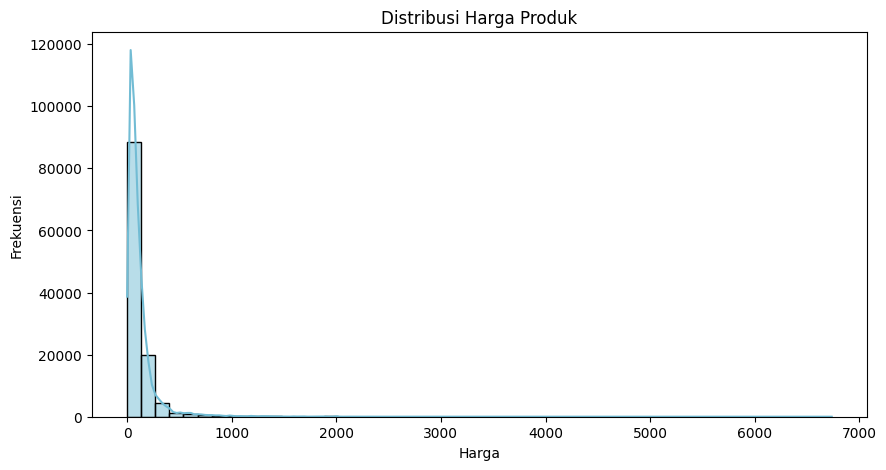

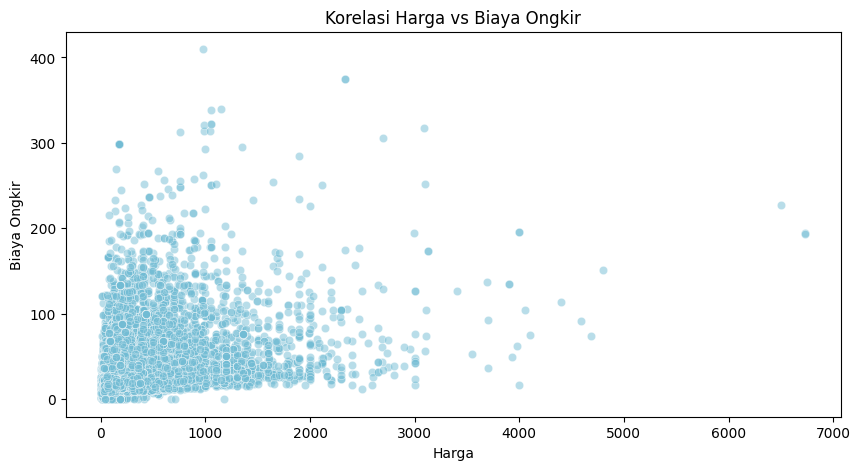

            order_purchase_timestamp              order_approved_at  \
count                         117604                         117589   
mean   2017-12-30 16:02:17.419356928  2017-12-31 03:30:37.187330304   
min              2016-09-04 21:15:19            2016-09-15 12:16:38   
25%              2017-09-11 21:23:29            2017-09-12 10:15:24   
50%              2018-01-18 13:33:08            2018-01-18 20:14:08   
75%       2018-05-03 22:41:39.500000            2018-05-04 11:35:10   
max              2018-09-03 09:06:57            2018-09-03 17:40:06   
std                              NaN                            NaN   

        order_delivered_carrier_date  order_delivered_customer_date  \
count                         116359                         115037   
mean   2018-01-03 17:57:37.331371008  2018-01-13 06:29:34.791693312   
min              2016-10-08 10:34:01            2016-10-11 13:46:32   
25%              2017-09-14 22:54:32            2017-09-25 13:56:47   
50%  

In [10]:
# EDA Univariate: Melihat distribusi harga produk (Price)
plt.figure(figsize=(10, 5))
sns.histplot(main_df['price'], bins=50, kde=True, color="#72BCD4") # Ganti ke main_df
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

# EDA Multivariate: Korelasi antara Harga (Price) dan Biaya Ongkir (Freight Value)
plt.figure(figsize=(10, 5))
sns.scatterplot(x='price', y='freight_value', data=main_df, color="#72BCD4", alpha=0.5) # Ganti ke main_df
plt.title('Korelasi Harga vs Biaya Ongkir')
plt.xlabel('Harga')
plt.ylabel('Biaya Ongkir')
plt.show()

# EDA Deskriptif: Statistik ringkasan untuk data numerik
print(main_df.describe()) # Ganti ke main_df

## Visualization & Explanatory Analysis

In [11]:
# Menyiapkan dataframe yang difilter untuk periode 2017 - pertengahan 2018
main_df_filtered = main_df[(main_df["order_purchase_timestamp"] >= "2017-01-01") & 
                           (main_df["order_purchase_timestamp"] <= "2018-06-30")]

# Menghitung ulang untuk Pertanyaan 1 menggunakan data terfilter
top_categories_count = main_df_filtered.groupby("product_category_name_english").product_id.count().sort_values(ascending=False).reset_index()
top_categories_revenue = main_df_filtered.groupby("product_category_name_english").price.sum().sort_values(ascending=False).reset_index()

### Pertanyaan 1: Produk apa yang paling banyak terjual dan kategori mana yang memberikan pendapatan tertinggi selama periode 2017-2018?

C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\1232507501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="product_id", y="product_category_name_english", data=top_categories_count.head(5), palette=colors, ax=ax[0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\1232507501.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=top_categories_revenue.head(5), palette=colors, ax=ax[1])


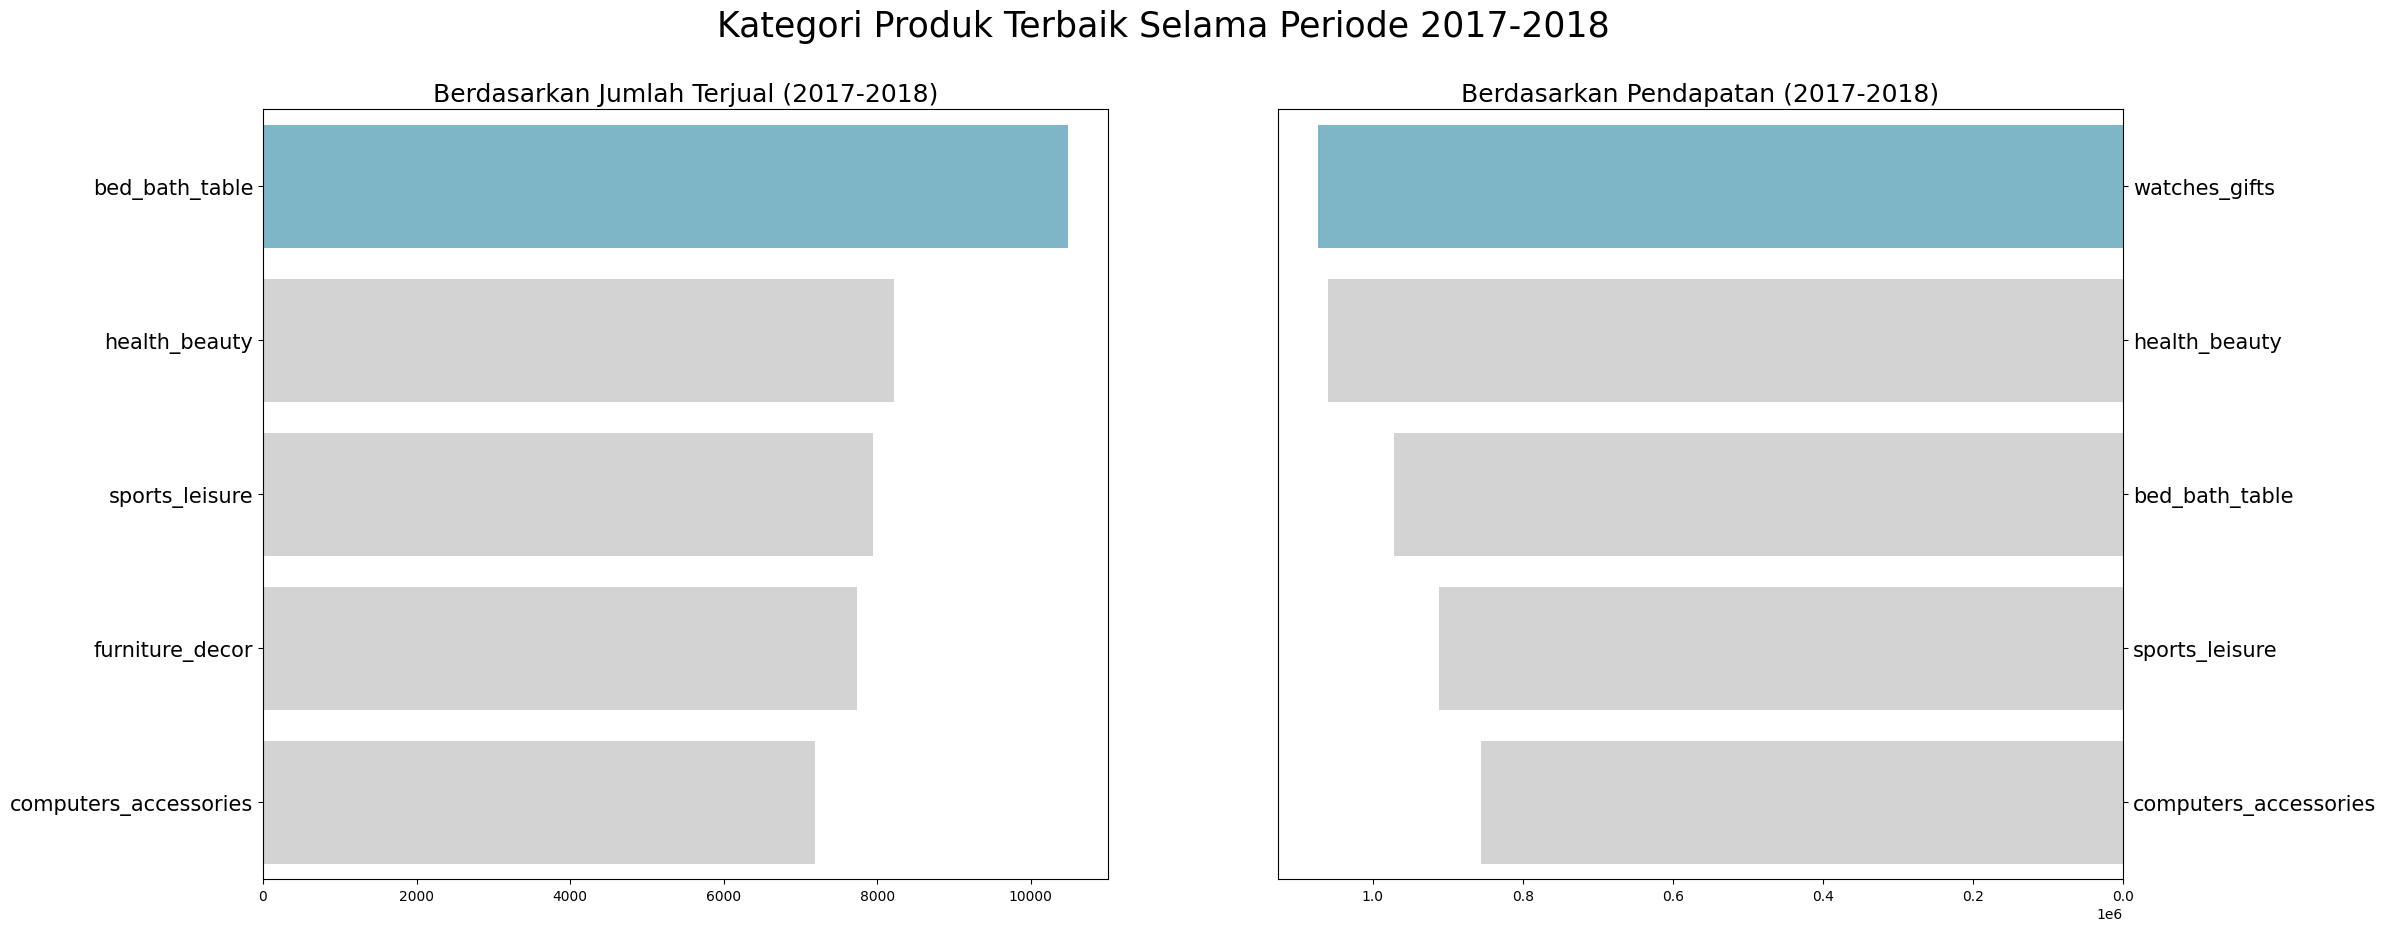

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Bar Chart 1: Produk Terlaris (Quantity) - Menggunakan top_categories_count (hasil filter)
sns.barplot(x="product_id", y="product_category_name_english", data=top_categories_count.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Berdasarkan Jumlah Terjual (2017-2018)", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

# Bar Chart 2: Pendapatan Tertinggi (Revenue) - Menggunakan top_categories_revenue (hasil filter)
sns.barplot(x="price", y="product_category_name_english", data=top_categories_revenue.head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis() 
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Berdasarkan Pendapatan (2017-2018)", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Kategori Produk Terbaik Selama Periode 2017-2018", fontsize=25)
plt.show()

### Pertanyaan 2: Bagaimana tren performa penjualan perusahaan setiap bulannya selama periode 2017 hingga pertengahan 2018?

C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\3784149575.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = monthly_orders_filtered.resample(rule='M', on='order_purchase_timestamp').agg({


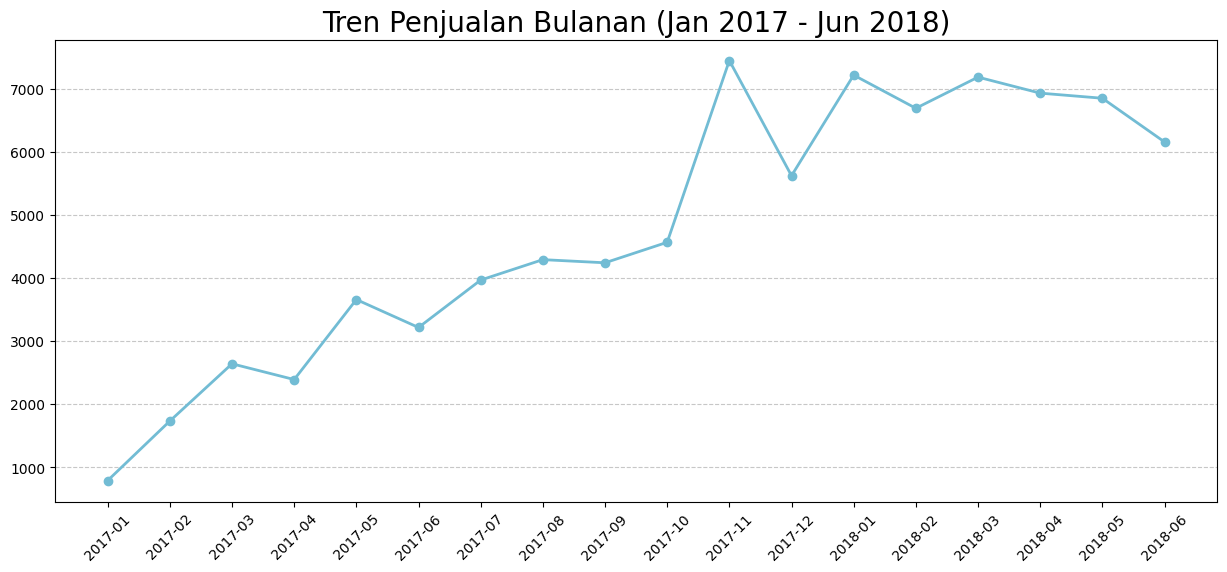

In [13]:
daily_orders_df = main_df.resample(rule='D', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()
daily_orders_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

# Memastikan dataframe bulanan sudah difilter
monthly_orders_filtered = daily_orders_df[(daily_orders_df["order_purchase_timestamp"] >= "2017-01-01") & 
                                          (daily_orders_df["order_purchase_timestamp"] <= "2018-06-30")]

# Resample ke bulanan untuk tren
monthly_trend = monthly_orders_filtered.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_count": "sum"
}).reset_index()

monthly_trend['order_month'] = monthly_trend['order_purchase_timestamp'].dt.strftime('%Y-%m')

plt.figure(figsize=(15, 6))
plt.plot(
    monthly_trend["order_month"],
    monthly_trend["order_count"],
    marker='o', 
    linewidth=2,
    color="#72BCD4"
)
plt.title("Tren Penjualan Bulanan (Jan 2017 - Jun 2018)", loc="center", fontsize=20)
plt.xticks(fontsize=10, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Analisis Lanjutan: RFM Analysis
Untuk menjawab pertanyaan bisnis ke-3, kita akan melakukan analisis RFM guna mengidentifikasi segmen pelanggan terbaik.
- **Recency**: Seberapa baru pelanggan melakukan transaksi?
- **Frequency**: Seberapa sering pelanggan melakukan transaksi?
- **Monetary**: Seberapa besar pendapatan yang dihasilkan dari pelanggan tersebut?

In [14]:
# Menentukan tanggal referensi (biasanya sehari setelah tanggal transaksi terakhir di dataset)
now = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Menghitung RFM
rfm_df = main_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (now - x.max()).days, # Recency
    "order_id": "nunique", # Frequency
    "price": "sum" # Monetary
})

# Mengganti nama kolom
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

# Tampilkan 5 data teratas hasil RFM
print(rfm_df.head())

                        customer_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90
2  0000f46a3911fa3c0805444483337064      542          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      293          1    180.00


C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\2086648250.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\2086648250.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
C:\Users\Asus\AppData\Local\Temp\ipykernel_30600\2086648250.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

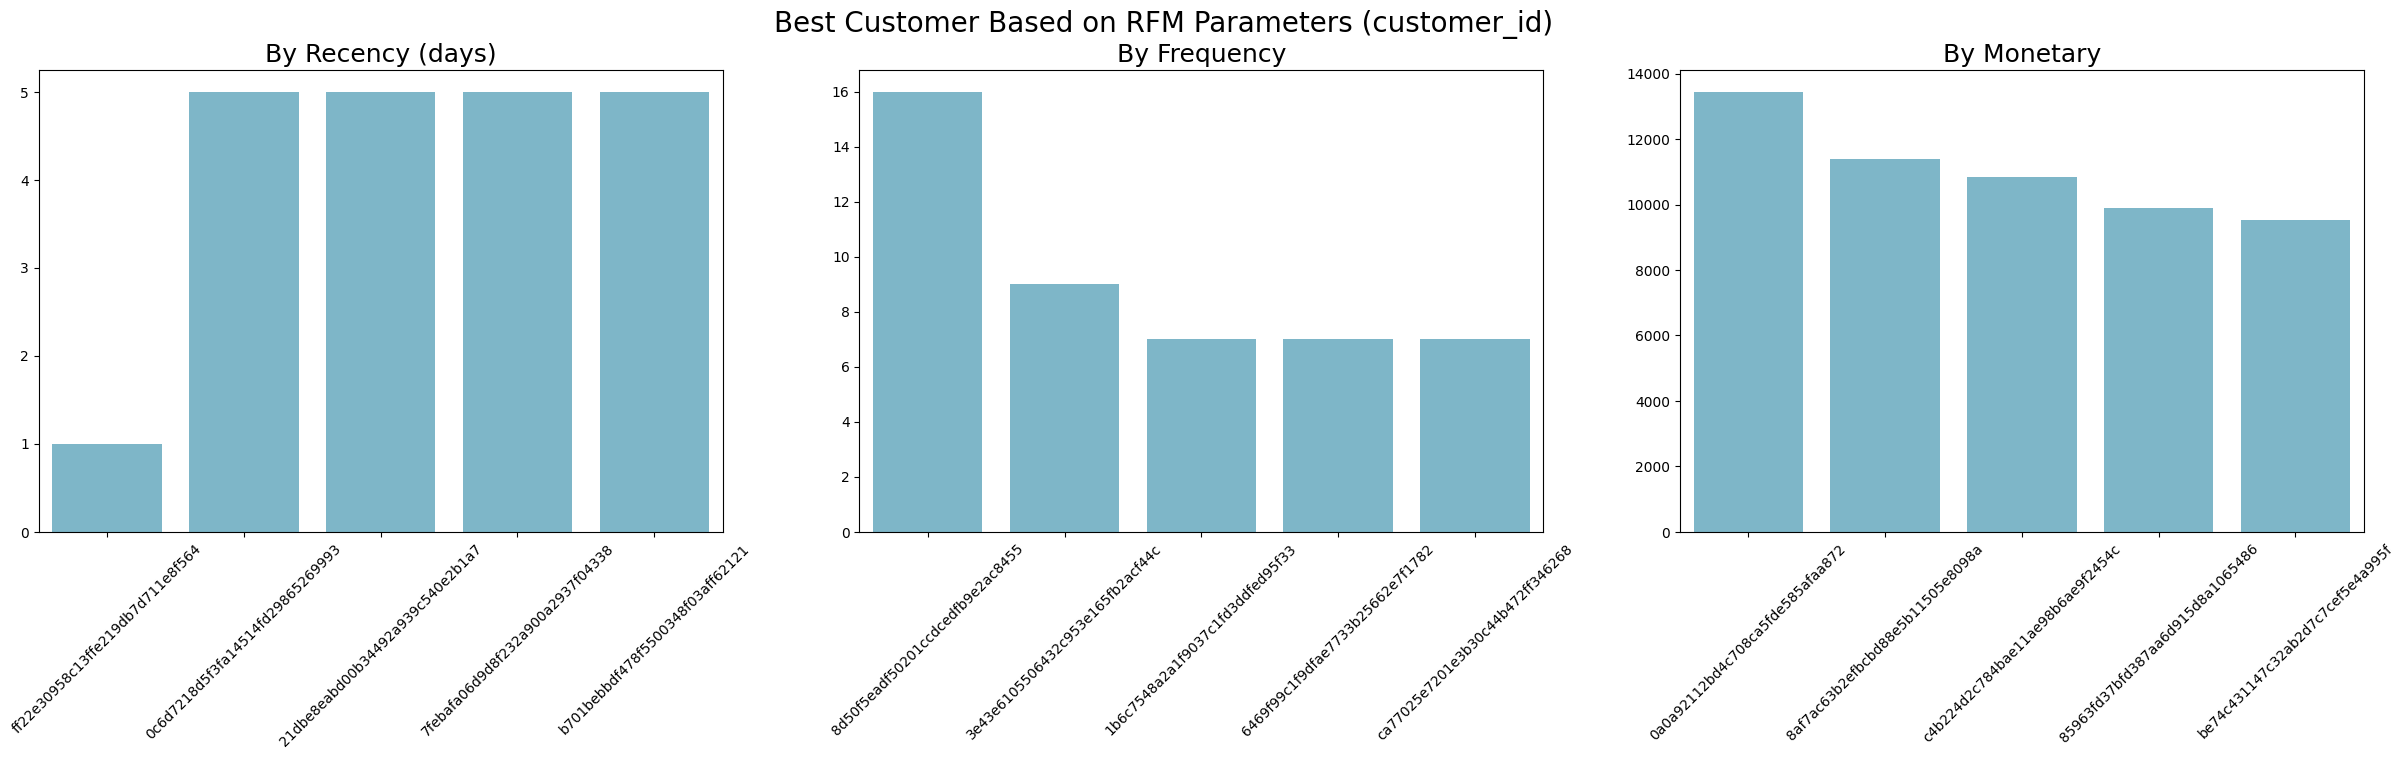

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Visualisasi Berdasarkan Recency (Hari terkecil adalah yang terbaik)
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', rotation=45)

# Visualisasi Berdasarkan Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Visualisasi Berdasarkan Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()

### Konklusi Pertanyaan 3:
Berdasarkan analisis RFM, kita dapat mengidentifikasi pelanggan yang paling baru melakukan transaksi (Recency), paling sering belanja (Frequency), dan memberikan kontribusi pendapatan terbesar (Monetary). 
- Mayoritas pelanggan di dataset ini memiliki frekuensi belanja sebanyak 1 kali, yang menunjukkan tantangan dalam retensi pelanggan.
- Strategi pemasaran dapat difokuskan pada pelanggan dengan *Recency* rendah dan *Monetary* tinggi untuk program loyalitas khusus agar mereka terus kembali bertransaksi.

### Export Data

In [16]:
# Simpan dataframe yang sudah bersih ke folder dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)

## Conclusion

- **Konklusi Pertanyaan 1:** Berdasarkan data periode 2017-2018, kategori **bed_bath_table** memiliki jumlah terjual terbanyak, namun kategori **health_beauty** memberikan revenue tertinggi. Hal ini menunjukkan produk kesehatan memiliki nilai jual rata-rata yang lebih tinggi.
- **Konklusi Pertanyaan 2:** Tren penjualan menunjukkan pertumbuhan yang konsisten sejak awal 2017 dan mencapai puncak pada November 2017.
- **Konklusi Pertanyaan 3:** Mayoritas pelanggan hanya melakukan transaksi satu kali. Perusahaan perlu fokus pada strategi retensi untuk meningkatkan loyalitas pelanggan.